In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ML-LastSem/Week5/FruitinAmazon.zip"
extract_to = ""

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

In [ ]:
!ls FruitinAmazon/train

acai  cupuacu  graviola  guarana  pupunha  tucuma


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
import torchvision.models as models
from sklearn.metrics import accuracy_score, classification_report

BASE_DIR = "FruitinAmazon"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = 6

# Standard ImageNet normalization required for pretrained VGG16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))
{c: i for i, c in enumerate(classes)}

{'acai': 0,
 'cupuacu': 1,
 'graviola': 2,
 'guarana': 3,
 'pupunha': 4,
 'tucuma': 5}

In [ ]:
class MyDataset(Dataset):
    def __init__(self, dir_path, is_train=False):
        self.dir_path = dir_path
        self.is_train = is_train
        self.classes = sorted(os.listdir(dir_path))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples = []
        for c in self.classes:
            class_folder = os.path.join(dir_path, c)
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                self.samples.append((img_path, self.class_to_idx[c]))

        self.train_transform = transforms.Compose([
            transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        self.val_transform = transforms.Compose([
            transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.is_train:
            img = self.train_transform(img)
        else:
            img = self.val_transform(img)
        return img, label

In [ ]:
# Create separate train and val datasets so val gets no augmentation
full_train_dataset= MyDataset(TRAIN_DIR, is_train=True)
full_val_dataset = MyDataset(TRAIN_DIR, is_train=False)  # same folder, no augmentation
test_dataset= MyDataset(TEST_DIR,  is_train=False)

val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

# Use the same random split indices for both datasets
train_dataset, _ = random_split(full_train_dataset,[train_size, val_size])
_, val_dataset = random_split(full_val_dataset,[train_size, val_size])

len(train_dataset), len(val_dataset), len(test_dataset)

(72, 18, 30)

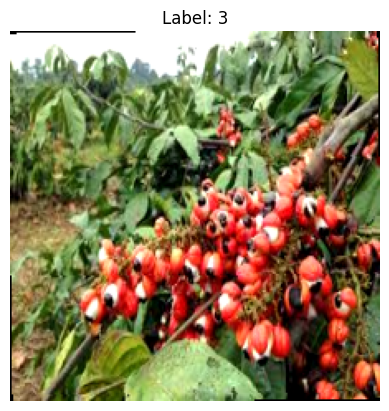

In [ ]:
image, label = train_dataset[1]
# Convert (C, H, W) -> (H, W, C) and undo normalization for display
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
image_to_show = (image * std + mean).permute(1, 2, 0).clamp(0, 1)
plt.imshow(image_to_show)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  pin_memory=True)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset,  batch_size=32, shuffle=False, pin_memory=True)

In [ ]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 126MB/s]


In [ ]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
for param in vgg16.features.parameters():
    param.requires_grad = False

In [ ]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES),
)

In [ ]:
vgg16 = vgg16.to(device)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [ ]:
learning_rate = 0.0003
epochs = 30

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate, weight_decay=1e-4)

early_stopper = EarlyStopping(patience=7, min_delta=0.001)

In [ ]:
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_val_loss   = float('inf')
checkpoint_path = 'best_model.pth'

for epoch in range(epochs):

    # train
    vgg16.train()
    total_train_loss, train_correct, train_total = 0, 0, 0

    for batch_features, batch_labels in train_loader:

        # move data to device (gpu)
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # forward pass
        outputs = vgg16(batch_features)

        # calculate  loss
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()

        # backprop
        loss.backward()

        # weight update
        optimizer.step()

        # calculate loss per batch
        total_train_loss += loss.item()
        train_correct += (outputs.argmax(dim=1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    # loss per epoch
    avg_loss = total_train_loss / len(train_loader)
    train_acc = train_correct / train_total

    # val
    vgg16.eval()
    total_epoch_val_loss = 0
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch_features, batch_labels in val_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            outputs = vgg16(batch_features)
            loss    = criterion(outputs, batch_labels)

            total_epoch_val_loss += loss.item()
            preds   = outputs.argmax(dim=1)
            correct += (preds == batch_labels).sum().item()
            total   += batch_labels.size(0)

    avg_val_loss = total_epoch_val_loss / len(val_loader)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(vgg16.state_dict(), checkpoint_path)
        print(f"------Best model saved at epoch {epoch+1}-------")

    val_acc = correct / total

    train_losses.append(avg_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch: {epoch+1} , Loss: {avg_loss:.4f} , Train Acc: {train_acc:.4f} , Val Loss: {avg_val_loss:.4f} , Val Acc: {val_acc:.4f}')

    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered. Training halted.")
        break

------Best model saved at epoch 1-------
Epoch: 1 , Loss: 1.7883 , Train Acc: 0.2361 , Val Loss: 1.0611 , Val Acc: 0.8333
------Best model saved at epoch 2-------
Epoch: 2 , Loss: 1.1784 , Train Acc: 0.5000 , Val Loss: 0.6770 , Val Acc: 0.8889
------Best model saved at epoch 3-------
Epoch: 3 , Loss: 0.8406 , Train Acc: 0.7361 , Val Loss: 0.3983 , Val Acc: 0.8333
------Best model saved at epoch 4-------
Epoch: 4 , Loss: 0.5393 , Train Acc: 0.8472 , Val Loss: 0.2307 , Val Acc: 0.9444
------Best model saved at epoch 5-------
Epoch: 5 , Loss: 0.4952 , Train Acc: 0.8333 , Val Loss: 0.1747 , Val Acc: 0.9444
Epoch: 6 , Loss: 0.2751 , Train Acc: 0.8611 , Val Loss: 0.2133 , Val Acc: 0.8889
Epoch: 7 , Loss: 0.1865 , Train Acc: 0.9306 , Val Loss: 0.2887 , Val Acc: 0.9444
Epoch: 8 , Loss: 0.1348 , Train Acc: 0.9583 , Val Loss: 0.3103 , Val Acc: 0.9444
Epoch: 9 , Loss: 0.0988 , Train Acc: 0.9583 , Val Loss: 0.2991 , Val Acc: 0.9444
Epoch: 10 , Loss: 0.1866 , Train Acc: 0.9583 , Val Loss: 0.2195 , 

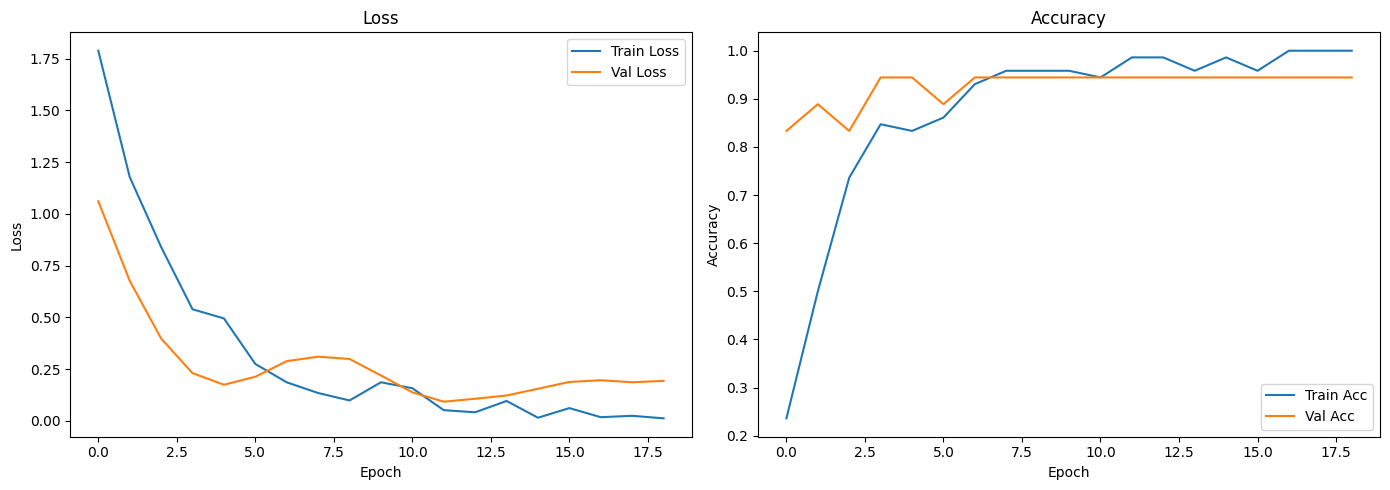

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(val_accs,   label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
vgg16.load_state_dict(torch.load(checkpoint_path, map_location=device))

vgg16.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = vgg16(batch_features)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

print(f'Test Accuracy: {accuracy_score(all_labels, all_preds)}')

Test Accuracy: 0.9333333333333333


In [ ]:
print(classification_report(all_labels, all_preds, target_names=full_train_dataset.classes))

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       1.00      1.00      1.00         5
    graviola       1.00      1.00      1.00         5
     guarana       0.83      1.00      0.91         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.80      0.89         5

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

